In [3]:
import pandas as pd
df=pd.read_csv("cleaned_dataset.csv")
df.head()
df.dtypes

,0
Student_ID,int64
Major_Category,object
Year_of_Study,object
Pre_Semester_GPA,float64
Weekly_GenAI_Hours,float64
Primary_Use_Case,object
Prompt_Engineering_Skill,object
Tool_Diversity,int64
Paid_Subscription,bool
Traditional_Study_Hours,float64


In [4]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
categorical_cols=df.select_dtypes(include=["object"]).columns
for col in categorical_cols:
    df[col]=le.fit_transform(df[col])

In [5]:
x = df.drop("Burnout_Risk_Level",axis=1)
y = df["Burnout_Risk_Level"]

In [6]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [7]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)
lr.fit(x_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [8]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state=42)
dt.fit(x_train, y_train)

DecisionTreeClassifier(random_state=42)

In [9]:
lr_pred = lr.predict(x_test)
dt_pred = dt.predict(x_test)

In [10]:
from sklearn.metrics import accuracy_score, precision_score,recall_score, f1_score
print("Logestic Regression")
print("Accuracy:",accuracy_score(y_test,lr_pred))
print("Precision:",precision_score(y_test,lr_pred, average='weighted'))
print("Recall:",recall_score(y_test,lr_pred, average='weighted'))
print("F1 Score:",f1_score(y_test,lr_pred, average='weighted'))

Logestic Regression
Accuracy: 0.5112
Precision: 0.5306280724421037
Recall: 0.5112
F1 Score: 0.5113716134269911


In [11]:
print("Decision Tree")
print("Accuracy:",accuracy_score(y_test,dt_pred))
print("Precision:",precision_score(y_test,dt_pred, average='weighted'))
print("Recall:",recall_score(y_test,dt_pred, average='weighted'))
print("F1 Score:",f1_score(y_test,dt_pred, average='weighted'))

Decision Tree
Accuracy: 0.4324
Precision: 0.4323864944127819
Recall: 0.4324
F1 Score: 0.43238876064700205


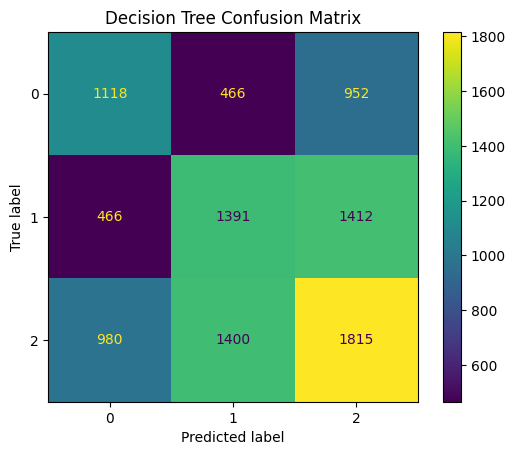

In [12]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
ConfusionMatrixDisplay.from_estimator(dt, x_test,y_test)
plt.title("Decision Tree Confusion Matrix")
plt.savefig("confusion_matrix.png")
plt.show()


In [13]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
param_grid = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}
grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5, scoring='accuracy')
grid_search.fit(x_train, y_train)



GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 5, 10, None],
                         'min_samples_split': [2, 5, 10]},
             scoring='accuracy')

In [14]:
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Accuracy:", grid_search.best_score_)

Best Parameters: {'criterion': 'gini', 'max_depth': 5, 'min_samples_split': 2}
Best Cross-Validation Accuracy: 0.523125


In [15]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(x_test)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))

Accuracy: 0.5236
Precision: 0.5431349056889571
Recall: 0.5236
F1 Score: 0.5210295657186985


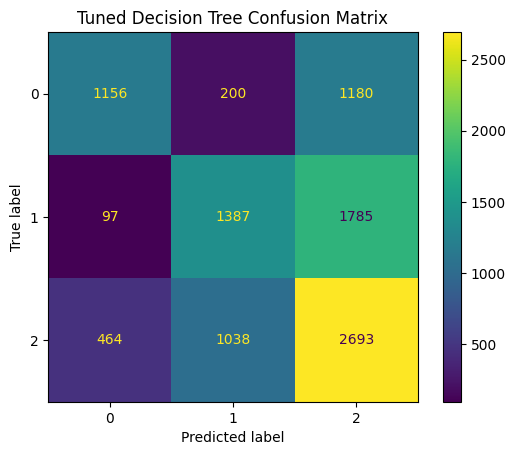

In [16]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
ConfusionMatrixDisplay.from_estimator(best_model, x_test,y_test)
plt.title("Tuned Decision Tree Confusion Matrix")
plt.savefig("tuned_confusion_matrix.png")
plt.show()